# ⚖️ Phase 2 – Bias & Fairness Validation
**Goal:** Detect and mitigate unfair model behaviour across demographic groups.

Topics:
- Disparate Impact
- Demographic Parity & Equal Opportunity
- Fairlearn MetricFrame
- Mitigation with Threshold Optimizer

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.metrics import accuracy_score, f1_score
print('Libraries ready!')

Libraries ready!


In [2]:
# Synthetic loan approval dataset
np.random.seed(42)
n = 2000
gender = np.random.choice(['Male', 'Female'], n, p=[0.55, 0.45])
age = np.random.randint(22, 65, n)
income = np.where(gender == 'Male',
                  np.random.normal(70000, 20000, n),
                  np.random.normal(55000, 18000, n))  # deliberate income gap
credit_score = np.random.randint(500, 800, n)
debt_ratio = np.random.uniform(0.1, 0.6, n)

# Biased approval logic (income-driven which correlates with gender)
log_odds = (-5 + 0.00004*income + 0.006*credit_score - 2*debt_ratio)
prob = 1 / (1 + np.exp(-log_odds))
approved = (np.random.rand(n) < prob).astype(int)

df = pd.DataFrame({'gender': gender, 'age': age, 'income': income,
                   'credit_score': credit_score, 'debt_ratio': debt_ratio,
                   'approved': approved})
print(df['approved'].value_counts())
print('\nApproval rate by gender:')
print(df.groupby('gender')['approved'].mean().round(3))

approved
1    1306
0     694
Name: count, dtype: int64

Approval rate by gender:
gender
Female    0.599
Male      0.698
Name: approved, dtype: float64


In [3]:
# Train baseline model
features = ['age', 'income', 'credit_score', 'debt_ratio']
X = df[features]
y = df['approved']
sensitive = df['gender']

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1: {f1_score(y_test, y_pred):.4f}')

Accuracy: 0.6650
F1: 0.7832


In [4]:
# Fairness audit with MetricFrame
mf = MetricFrame(
    metrics={'accuracy': accuracy_score, 'f1': f1_score,
             'approval_rate': lambda yt, yp: yp.mean()},
    y_true=y_test, y_pred=y_pred,
    sensitive_features=s_test
)

print('Metrics by gender group:')
display(mf.by_group)
print(f'\nDemographic Parity Difference: {demographic_parity_difference(y_test, y_pred, sensitive_features=s_test):.4f}')
print(f'Equalized Odds Difference:    {equalized_odds_difference(y_test, y_pred, sensitive_features=s_test):.4f}')
print('\n(0 = perfectly fair, >0.1 = concern, >0.2 = serious bias)')

Metrics by gender group:


,accuracy,f1,approval_rate
gender,,,
Female,0.624309,0.742424,0.861878
Male,0.698630,0.813559,0.949772



Demographic Parity Difference: 0.0879
Equalized Odds Difference:    0.0822

(0 = perfectly fair, >0.1 = concern, >0.2 = serious bias)


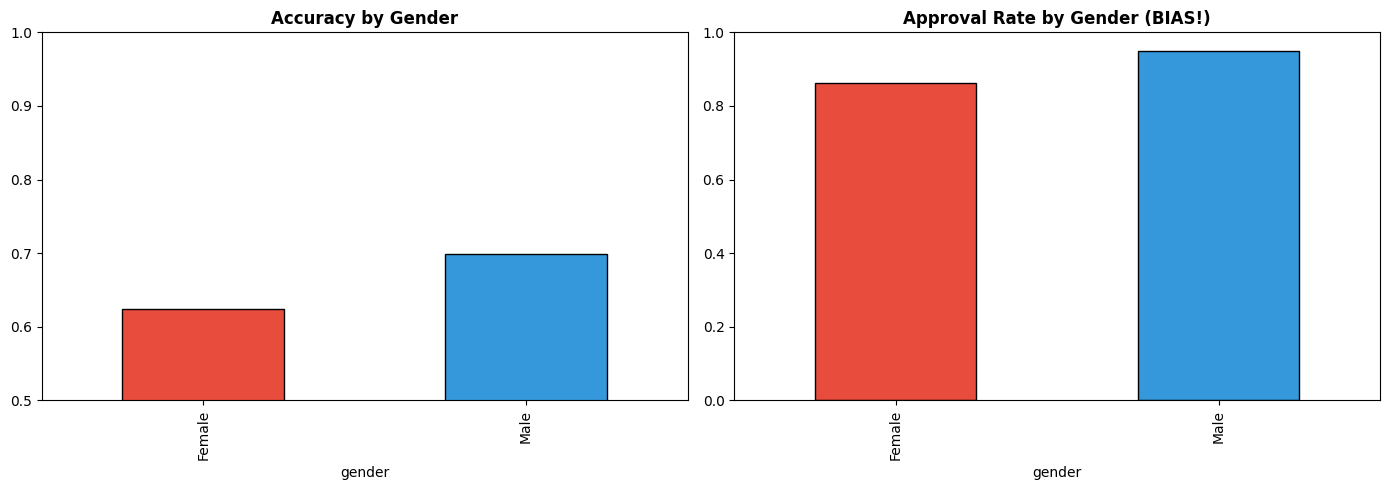

In [5]:
# Visualize disparity
by_group = mf.by_group[['accuracy', 'approval_rate']]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
by_group['accuracy'].plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db'], edgecolor='black')
axes[0].set_title('Accuracy by Gender', fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
by_group['approval_rate'].plot(kind='bar', ax=axes[1], color=['#e74c3c','#3498db'], edgecolor='black')
axes[1].set_title('Approval Rate by Gender (BIAS!)', fontweight='bold')
axes[1].set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('../data/fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Mitigation: ThresholdOptimizer
mitigator = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    constraints='demographic_parity',
    objective='accuracy_score',
    predict_method='predict_proba'
)
mitigator.fit(X_train, y_train, sensitive_features=s_train)
y_pred_fair = mitigator.predict(X_test, sensitive_features=s_test)

mf_fair = MetricFrame(
    metrics={'accuracy': accuracy_score, 'approval_rate': lambda yt, yp: yp.mean()},
    y_true=y_test, y_pred=y_pred_fair, sensitive_features=s_test
)
print('After mitigation:')
display(mf_fair.by_group)
print(f'New Demographic Parity Difference: {demographic_parity_difference(y_test, y_pred_fair, sensitive_features=s_test):.4f}')

After mitigation:


,accuracy,approval_rate
gender,,
Female,0.629834,0.922652
Male,0.698630,0.894977


New Demographic Parity Difference: 0.0277


## Key Fairness Definitions
| Metric | Definition |
|--------|------------|
| **Demographic Parity** | P(approve\|male) ≈ P(approve\|female) |
| **Equal Opportunity** | True Positive Rate same across groups |
| **Equalized Odds** | Both TPR and FPR equal across groups |
| **Disparate Impact** | Ratio of approval rates (80% rule: should be ≥ 0.8) |

**Exercise:** Try the `ExponentiatedGradient` reducer as an alternative mitigation strategy!